# SalesBuddy AI – Retail Sales Analytics Chatbot

## Project Overview
This project builds a simple retail sales analytics chatbot using Python and Pandas. 
The system allows users to explore a sales dataset using natural language style questions.

The notebook performs the following tasks:

1. Data loading from CSV file
2. Data preprocessing and cleaning
3. Exploratory data analysis
4. Implementation of a rule-based chatbot backend
5. Simple chatbot user interface for asking questions

The chatbot can answer questions such as:
- Total sales
- Average sales
- Top products
- Sales by month

In [16]:
#Import Libraries

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

## Step 1: Load Dataset

In this step, we load the retail sales dataset from a CSV file into a Pandas DataFrame.

In [7]:
df = pd.read_excel("sales_data.xlsx")

df.to_csv("sales_data.csv", index=False)

print(df.head())

                         transaction_id  customer_number transaction_month  \
0  6ae6b99d-9158-43f2-ac7e-52f17620fc40         75583263           2022-01   
1  6ae6b99d-9158-43f2-ac7e-52f17620fc40         75583263           2022-01   
2  6ae6b99d-9158-43f2-ac7e-52f17620fc40         75583263           2022-01   
3  6ae6b99d-9158-43f2-ac7e-52f17620fc40         75583263           2022-01   
4  a1e86962-46d7-4940-8759-b58c535b370b         75583263           2022-01   

  product_id                product_name  unit_price  volume_units  \
0       P021     Dettol Antiseptic 250ml      305.70            10   
1       P026  Kellogg's Corn Flakes 500g      405.20             5   
2       P009             Lays Chips 200g      322.60            10   
3       P037       Vim Dishwash Bar 200g      176.27             9   
4       P026  Kellogg's Corn Flakes 500g      477.55            10   

   sales_amount promo_offer  
0       3057.00         Yes  
1       2026.00         Yes  
2       3226.00     

## Step 2: Explore the Dataset

This step helps us understand the structure of the dataset.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82950 entries, 0 to 82949
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     82950 non-null  object 
 1   customer_number    82950 non-null  int64  
 2   transaction_month  82950 non-null  object 
 3   product_id         82950 non-null  object 
 4   product_name       82950 non-null  object 
 5   unit_price         82950 non-null  float64
 6   volume_units       82950 non-null  int64  
 7   sales_amount       82950 non-null  float64
 8   promo_offer        82950 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 5.7+ MB


In [9]:
df.describe()

,customer_number,unit_price,volume_units,sales_amount
count,8.295000e+04,82950.000000,82950.000000,82950.000000
mean,4.973458e+07,273.435430,5.497601,1503.266978
std,2.866339e+07,162.663667,2.873561,1280.993174
min,3.277000e+03,29.220000,1.000000,29.570000
25%,2.432787e+07,127.200000,3.000000,504.490000
50%,4.978368e+07,243.490000,5.000000,1095.100000
75%,7.489914e+07,378.760000,8.000000,2219.805000
max,9.996990e+07,582.850000,10.000000,5828.500000


## Step 3: Data Cleaning

In this step we clean the dataset by removing duplicate records and handling missing values.

In [11]:
df.drop_duplicates(inplace=True)

df.fillna(0, inplace=True)

df.head()

,transaction_id,customer_number,transaction_month,product_id,product_name,unit_price,volume_units,sales_amount,promo_offer
0,6ae6b99d-9158-43f2-ac7e-52f17620fc40,75583263,2022-01,P021,Dettol Antiseptic 250ml,305.70,10,3057.00,Yes
1,6ae6b99d-9158-43f2-ac7e-52f17620fc40,75583263,2022-01,P026,Kellogg's Corn Flakes 500g,405.20,5,2026.00,Yes
2,6ae6b99d-9158-43f2-ac7e-52f17620fc40,75583263,2022-01,P009,Lays Chips 200g,322.60,10,3226.00,Yes
3,6ae6b99d-9158-43f2-ac7e-52f17620fc40,75583263,2022-01,P037,Vim Dishwash Bar 200g,176.27,9,1586.43,Yes
4,a1e86962-46d7-4940-8759-b58c535b370b,75583263,2022-01,P026,Kellogg's Corn Flakes 500g,477.55,10,4775.50,No


## Step 4: Basic Data Analysis

Here we compute important statistics from the dataset.

In [12]:
# total sales

total_sales = df["sales_amount"].sum()

print("Total Sales:", total_sales)

Total Sales: 124695995.83


In [13]:
# average sales

avg_sales = df["sales_amount"].mean()

print("Average Sales:", avg_sales)

Average Sales: 1503.2669780590718


## Step 5: Monthly Sales Analysis

This analysis shows how sales change over different months.

In [14]:
monthly_sales = df.groupby("transaction_month")["sales_amount"].sum()

monthly_sales

transaction_month
2022-01    1641784.46
2022-02    3006115.15
2022-03    4214472.09
2022-04    5287652.14
2022-05    5536292.74
2022-06    5840271.84
2022-07    5842066.12
2022-08    6165023.84
2022-09    6191852.10
2022-10    6028041.60
2022-11    5855565.39
2022-12    6261031.43
2023-01    6304850.32
2023-02    5954485.11
2023-03    6481715.86
2023-04    6035719.68
2023-05    6335254.62
2023-06    6011657.79
2023-07    6063637.37
2023-08    5698299.69
2023-09    5131903.82
2023-10    4030371.81
2023-11    3052154.21
2023-12    1725776.65
Name: sales_amount, dtype: float64

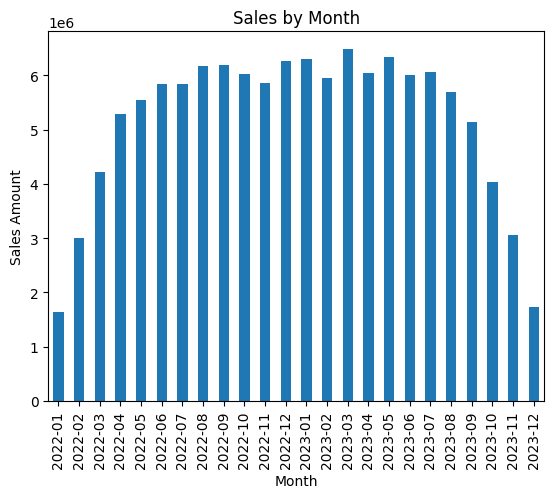

In [17]:
# chart

monthly_sales.plot(kind="bar")

plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales Amount")

plt.show()

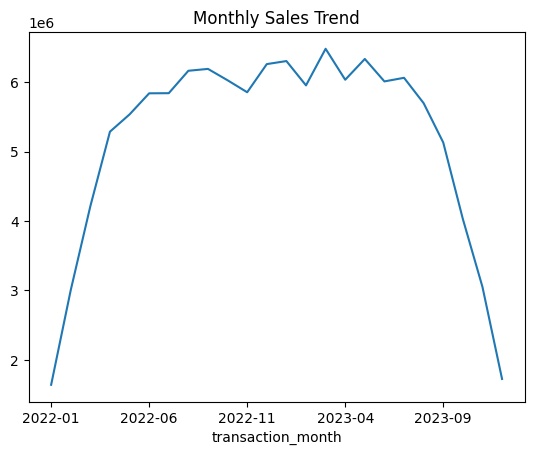

In [24]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line")

plt.title("Monthly Sales Trend")

plt.show()

## Step 6: Top Products Analysis

In [19]:
top_products = df.groupby("product_name")["sales_amount"].sum().sort_values(ascending=False)

top_products.head(10)

product_name
Godrej Shampoo 200ml          6291047.29
Milky Mist Paneer 200g        6278408.60
Santoor Soap 75g              6029465.11
Pepsodent Combo Pack          5902345.04
Dove Soap 75g                 5534074.21
Red Label Tea 250g            5374852.36
Palmolive Shampoo 180ml       5312118.65
Kellogg's Corn Flakes 500g    5098624.12
Amul Butter 100g              4783230.37
Dabur Honey 500g              4732191.67
Name: sales_amount, dtype: float64

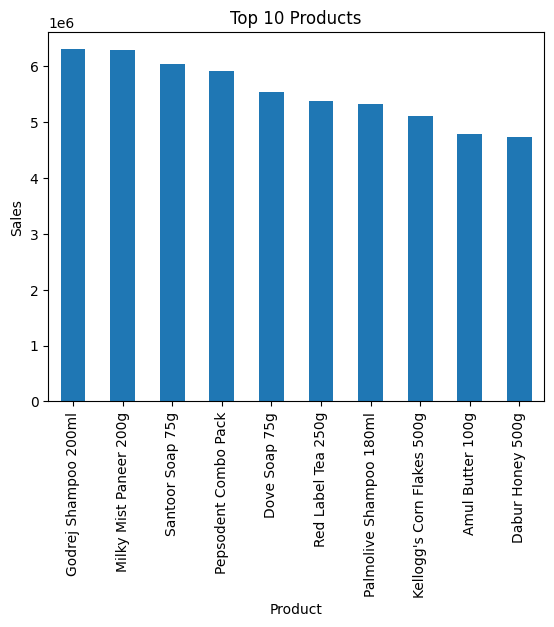

In [21]:
# chart 

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

## Step 7: Chatbot Backend Logic

This section implements a simple rule-based chatbot that can answer
questions related to the sales dataset.

In [22]:
def chatbot_response(query):

    query = query.lower()

    if "total sales" in query:
        return df["sales_amount"].sum()

    elif "average sales" in query:
        return df["sales_amount"].mean()

    elif "top product" in query:
        return df.groupby("product")["sales_amount"].sum().idxmax()

    elif "sales by month" in query:
        return df.groupby("month")["sales_amount"].sum()

    else:
        return "Sorry, I don't understand the question."

## Step 8: Chatbot Interface

The user can type a question and the chatbot will return the answer.

In [23]:
while True:

    user_query = input("Ask a sales question (type 'exit' to stop): ")

    if user_query.lower() == "exit":
        print("Chatbot session ended.")
        break

    response = chatbot_response(user_query)

    print("Chatbot:", response)

Chatbot: 124695995.83
Chatbot: 124695995.83
Chatbot: Sorry, I don't understand the question.
Chatbot: Sorry, I don't understand the question.
Chatbot: Sorry, I don't understand the question.
Chatbot session ended.


# python code

import streamlit as st
import pandas as pd
import sqlite3
import time

# -------------------------
# Page Config
# -------------------------

st.set_page_config(layout="wide")

# -------------------------
# Connect to SQLite Database
# -------------------------

conn = sqlite3.connect("sales.db")

# -------------------------
# Session State
# -------------------------

if "chat_history" not in st.session_state:
    st.session_state.chat_history = []

if "user_question" not in st.session_state:
    st.session_state.user_question = ""

# -------------------------
# Sidebar
# -------------------------

st.sidebar.header("💡 Suggested Questions")

suggestions = [
    "Total Sales",
    "Total Orders",
    "Average Sales",
    "Top Product",
    "Sales by Month",
    "Promo Impact"
]

for s in suggestions:
    if st.sidebar.button(s):
        st.session_state.user_question = s.lower()

# -------------------------
# Product Dashboard
# -------------------------

st.sidebar.header("📊 Product Dashboard")

if st.sidebar.button("Show Top 10 Products"):

    query = """
    SELECT product_name, SUM(sales_amount) as revenue
    FROM sales
    GROUP BY product_name
    ORDER BY revenue DESC
    LIMIT 10
    """

    df = pd.read_sql_query(query, conn)

    st.subheader("🏆 Top 10 Products by Revenue")

    st.dataframe(df)

    st.bar_chart(df.set_index("product_name"))

# -------------------------
# Layout Columns
# -------------------------

col_main, col_chat = st.columns([3,1])

# =========================
# MAIN AREA
# =========================

with col_main:

    st.title("🤖 SalesBuddy AI — Retail Sales Analytics Assistant")

    st.write(
        "Analyze sales trends, product performance, and promotional impact using natural language queries."
    )

    # -------------------------
    # KPI Dashboard
    # -------------------------

    kpi_query = """
    SELECT 
    SUM(sales_amount) as total_sales,
    COUNT(DISTINCT transaction_id) as total_orders,
    AVG(sales_amount) as avg_sales
    FROM sales
    """

    kpi_df = pd.read_sql_query(kpi_query, conn)

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Total Sales",
            f"₹{kpi_df['total_sales'][0]:,.0f}"
        )

    with col2:
        st.metric(
            "Total Orders",
            f"{kpi_df['total_orders'][0]:,}"
        )

    with col3:
        st.metric(
            "Average Sales",
            f"₹{kpi_df['avg_sales'][0]:,.2f}"
        )

    st.divider()

    user_question = st.text_input(
        "Ask questions about your sales data and get instant insights",
        value=st.session_state.user_question,
        placeholder="Example: Show top products by sales"
    )

# -------------------------
# Question → SQL Mapping
# -------------------------

def generate_sql(question):

    q = question.lower()

    if "total sales" in q:
        return "SELECT SUM(sales_amount) AS total_sales FROM sales"

    elif "total orders" in q:
        return "SELECT COUNT(DISTINCT transaction_id) AS total_orders FROM sales"

    elif "average sales" in q:
        return "SELECT AVG(sales_amount) AS average_sales FROM sales"

    elif "top product" in q:
        return """
        SELECT product_name, SUM(volume_units) as total_units
        FROM sales
        GROUP BY product_name
        ORDER BY total_units DESC
        LIMIT 5
        """

    elif "sales by month" in q:
        return """
        SELECT transaction_month, SUM(sales_amount) as monthly_sales
        FROM sales
        GROUP BY transaction_month
        """

    elif "promo impact" in q:
        return """
        SELECT promo_offer, SUM(sales_amount) as total_sales
        FROM sales
        GROUP BY promo_offer
        """

    else:
        return None


# -------------------------
# Process Question
# -------------------------

if user_question:

    start = time.time()

    sql_query = generate_sql(user_question)

    if sql_query:

        with st.spinner("SalesBuddy is analyzing your data..."):

            result = pd.read_sql_query(sql_query, conn)

            time.sleep(0.5)

        end = time.time()
        response_time = round(end - start, 3)

        # Save chat history
        st.session_state.chat_history.append(("User", user_question))
        st.session_state.chat_history.append(("SalesBuddy", f"Returned {len(result)} records"))

        # keep last 10 messages
        st.session_state.chat_history = st.session_state.chat_history[-10:]

        with col_main:

            # -------------------------
            # Display Result
            # -------------------------

            st.subheader("Result")

            st.dataframe(result)

            st.write(f"⏱ Response time: {response_time} seconds")

            # -------------------------
            # Charts
            # -------------------------

            if "monthly_sales" in result.columns:

                st.subheader("📈 Monthly Sales Trend")

                st.line_chart(result.set_index("transaction_month"))

            if "total_units" in result.columns:

                st.subheader("🏆 Top Products")

                st.bar_chart(result.set_index("product_name"))

            if "promo_offer" in result.columns:

                st.subheader("🎯 Promotion Impact")

                st.bar_chart(result.set_index("promo_offer"))

            # -------------------------
            # Business Insights
            # -------------------------

            st.subheader("📊 Business Insights")

            if "total_sales" in result.columns:

                value = float(result["total_sales"].iloc[0])

                st.info(f"Total revenue generated is **₹{value:,.2f}**.")

            if "total_units" in result.columns:

                top_product = result.iloc[0]["product_name"]

                st.info(
                    f"Top performing product is **{top_product}** based on units sold."
                )

            if "promo_offer" in result.columns and "total_sales" in result.columns:

                best = result.loc[result["total_sales"].astype(float).idxmax()]

                promo_type = best["promo_offer"]

                promo_sales = float(best["total_sales"])

                if promo_type == "Yes":
                    text = "when promotions are applied"
                else:
                    text = "without promotions"

                st.info(
                    f"Sales are highest **{text}**, generating revenue of **₹{promo_sales:,.2f}**."
                )

            # -------------------------
            # AI Insight
            # -------------------------

            st.subheader("🧠 SalesBuddy Insight")

            if "monthly_sales" in result.columns:

                best_month = result.loc[result["monthly_sales"].idxmax()]

                st.success(
                    f"Highest sales occurred in **Month {best_month['transaction_month']}**."
                )


# =========================
# CHAT HISTORY (RIGHT SIDE)
# =========================

with col_chat:

    st.subheader("💬 Chat History")

    if st.session_state.chat_history:

        chat_df = pd.DataFrame(
            st.session_state.chat_history,
            columns=["Role", "Message"]
        )

        st.dataframe(chat_df, use_container_width=True)

    else:
        st.info("No conversation yet.")

    # -------------------------
    # Download Chat Report
    # -------------------------

    if st.session_state.chat_history:

        report_data = []

        for role, msg in st.session_state.chat_history:

            report_data.append({
                "role": role,
                "content": msg
            })

        report_df = pd.DataFrame(report_data)

        st.download_button(
            label="📥 Download Chat Report",
            data=report_df.to_csv(index=False),
            file_name="chat_report.csv",
            mime="text/csv"
        )

# -------------------------
# Footer
# -------------------------

st.markdown("---")
st.caption("SalesBuddy AI | Retail Analytics Dashboard | Built with Streamlit, SQL, and Python")

In [12]:
conn = sqlite3.connect("sales.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

82950

chatbot ui